In [26]:
import os, random, numpy as np, tensorflow as tf

SEED = 42

os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

In [27]:
import os
import numpy as np
import pandas as pd
import librosa

from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D, Dense, Dropout, BatchNormalization, Bidirectional, LSTM
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

In [28]:
df_train = pd.read_csv(r"D:\SER_Cross\data\processed\train.csv")
df_val   = pd.read_csv(r"D:\SER_Cross\data\processed\val.csv")
df_test  = pd.read_csv(r"D:\SER_Cross\data\processed\test.csv")

In [29]:
df_train = df_train[df_train['emotion'].isin(['angry', 'happy', 'sad'])]
df_val   = df_val[df_val['emotion'].isin(['angry', 'happy', 'sad'])]
df_test  = df_test[df_test['emotion'].isin(['angry', 'happy', 'sad'])]

In [30]:
def extract_mfcc_delta(file_path):
    y, sr = librosa.load(file_path, sr=22050)

    max_len = 3 * sr
    if len(y) < max_len:
        y = np.pad(y, (0, max_len - len(y)))
    else:
        y = y[:max_len]

    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_mfcc=40)
    delta = librosa.feature.delta(mfcc)
    delta2 = librosa.feature.delta(mfcc, order=2)

    combined = np.vstack((mfcc, delta, delta2))  # (120, T)

    return combined.T   # (T, 120) for Conv1D

In [31]:
def process_dataframe(df):
    X, y = [], []

    for _, row in df.iterrows():
        file_path = row['path']
        label = row['emotion']

        try:
            features = extract_mfcc_delta(file_path)
            X.append(features)
            y.append(label)
        except:
            continue

    return np.array(X), np.array(y)

In [32]:
X_train, y_train = process_dataframe(df_train)
X_val, y_val     = process_dataframe(df_val)
X_test, y_test   = process_dataframe(df_test)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)

Train: (3084, 130, 120)
Val: (621, 130, 120)
Test: (684, 130, 120)


In [33]:
X_train = (X_train - np.mean(X_train)) / np.std(X_train)
X_val   = (X_val - np.mean(X_val)) / np.std(X_val)
X_test  = (X_test - np.mean(X_test)) / np.std(X_test)

In [34]:
le = LabelEncoder()

y_train_enc = le.fit_transform(y_train)
y_val_enc   = le.transform(y_val)
y_test_enc  = le.transform(y_test)

y_train_cat = to_categorical(y_train_enc)
y_val_cat   = to_categorical(y_val_enc)
y_test_cat  = to_categorical(y_test_enc)

In [35]:
model = Sequential()

# Conv Block 1
model.add(Conv1D(64, 3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))
model.add(Dropout(0.3))

# Conv Block 2
model.add(Conv1D(128, 3, activation='relu'))
model.add(BatchNormalization())
model.add(MaxPooling1D(2))
model.add(Dropout(0.3))

# BiLSTM Block (IMPROVED)
model.add(Bidirectional(LSTM(160, return_sequences=True)))
model.add(Bidirectional(LSTM(64)))

# Dense
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.2))

model.add(Dense(3, activation='softmax'))

model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv1d_2 (Conv1D)           (None, 128, 64)           23104     
                                                                 
 batch_normalization_2 (Bat  (None, 128, 64)           256       
 chNormalization)                                                
                                                                 
 max_pooling1d_2 (MaxPoolin  (None, 64, 64)            0         
 g1D)                                                            
                                                                 
 dropout_3 (Dropout)         (None, 64, 64)            0         
                                                                 
 conv1d_3 (Conv1D)           (None, 62, 128)           24704     
                                                                 
 batch_normalization_3 (Bat  (None, 62, 128)          

In [36]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

In [37]:
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=3,
    min_lr=1e-5
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [38]:
history = model.fit(
    X_train, y_train_cat,
    validation_data=(X_val, y_val_cat),
    epochs=50,
    batch_size=32,
    callbacks=[lr_scheduler, early_stop]
)

Epoch 1/50
97/97 [==============================] - 14s 93ms/step - loss: 0.7475 - accuracy: 0.6553 - val_loss: 1.0353 - val_accuracy: 0.4799 - lr: 0.0010
Epoch 2/50
97/97 [==============================] - 7s 69ms/step - loss: 0.6497 - accuracy: 0.7049 - val_loss: 1.2034 - val_accuracy: 0.5201 - lr: 0.0010
Epoch 3/50
97/97 [==============================] - 7s 73ms/step - loss: 0.5930 - accuracy: 0.7393 - val_loss: 0.9748 - val_accuracy: 0.5652 - lr: 0.0010
Epoch 4/50
97/97 [==============================] - 7s 70ms/step - loss: 0.5387 - accuracy: 0.7811 - val_loss: 0.9886 - val_accuracy: 0.6200 - lr: 0.0010
Epoch 5/50
97/97 [==============================] - 7s 69ms/step - loss: 0.4975 - accuracy: 0.7922 - val_loss: 1.1291 - val_accuracy: 0.5862 - lr: 0.0010
Epoch 6/50
97/97 [==============================] - 7s 70ms/step - loss: 0.4738 - accuracy: 0.7980 - val_loss: 1.2510 - val_accuracy: 0.5266 - lr: 0.0010
Epoch 7/50
97/97 [==============================] - 7s 72ms/step - loss: 0.

In [39]:
test_loss, test_acc = model.evaluate(X_test, y_test_cat)

print(" CRNN Test Accuracy:", test_acc)

22/22 [==============================] - 1s 25ms/step - loss: 0.5068 - accuracy: 0.7953
 CRNN Test Accuracy: 0.7953216433525085


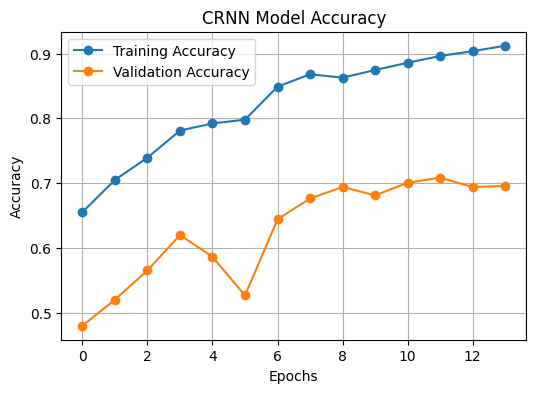

In [40]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))

plt.plot(history.history['accuracy'], marker='o')
plt.plot(history.history['val_accuracy'], marker='o')

plt.title('CRNN Model Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

plt.legend(['Training Accuracy', 'Validation Accuracy'])
plt.grid(True)

plt.savefig('crnn_accuracy.png', dpi=300, bbox_inches='tight')
plt.show()

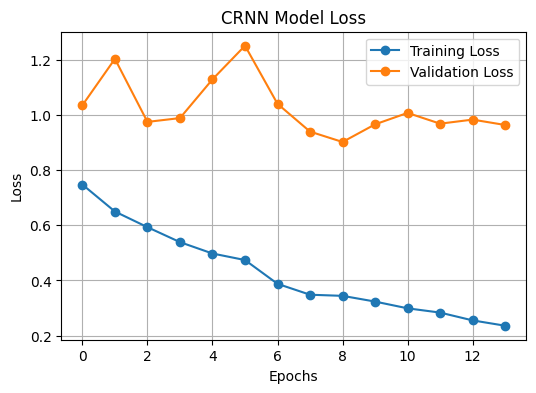

In [41]:
plt.figure(figsize=(6,4))

plt.plot(history.history['loss'], marker='o')
plt.plot(history.history['val_loss'], marker='o')

plt.title('CRNN Model Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.legend(['Training Loss', 'Validation Loss'])
plt.grid(True)

plt.savefig('crnn_loss.png', dpi=300, bbox_inches='tight')
plt.show()

22/22 [==============================] - 1s 19ms/step


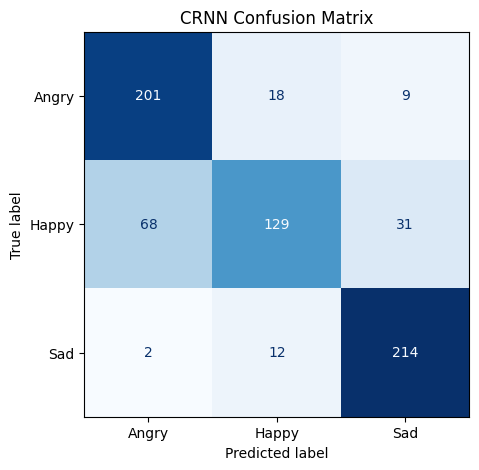

In [42]:
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)

# True labels
y_true = np.argmax(y_test_cat, axis=1)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred_classes)

labels = ['Angry', 'Happy', 'Sad']

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(5,5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)

plt.title('CRNN Confusion Matrix')
plt.savefig('cnn_confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

In [43]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred_classes,
    target_names=['Angry', 'Happy', 'Sad']
)

print(report)

              precision    recall  f1-score   support

       Angry       0.74      0.88      0.81       228
       Happy       0.81      0.57      0.67       228
         Sad       0.84      0.94      0.89       228

    accuracy                           0.80       684
   macro avg       0.80      0.80      0.79       684
weighted avg       0.80      0.80      0.79       684



In [44]:
import pandas as pd

report_dict = classification_report(
    y_true,
    y_pred_classes,
    target_names=['Angry', 'Happy', 'Sad'],
    output_dict=True
)

df_report = pd.DataFrame(report_dict).transpose()
print(df_report)

              precision    recall  f1-score     support
Angry          0.741697  0.881579  0.805611  228.000000
Happy          0.811321  0.565789  0.666667  228.000000
Sad            0.842520  0.938596  0.887967  228.000000
accuracy       0.795322  0.795322  0.795322    0.795322
macro avg      0.798513  0.795322  0.786748  684.000000
weighted avg   0.798513  0.795322  0.786748  684.000000


In [45]:
print(" Training Accuracy:", history.history['accuracy'][-1])

 Training Accuracy: 0.9121271371841431


In [46]:
print(" Validation Accuracy:", max(history.history['val_accuracy']))

 Validation Accuracy: 0.7085345983505249


In [47]:
model.save("crnn_model.h5")   

c:\Users\Asus\anaconda3\envs\ser_env\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(
